In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
from pypalettes import load_cmap
import matplotlib.pyplot as plt
from plotnine import *
import os


# Cleaning Data

In [13]:
print("Current working directory:", os.getcwd())

Current working directory: /Users/michael/Desktop/Website Data


In [12]:
mycwd = os.getcwd()
os.chdir("..")
#os.chdir(mycwd)

In [14]:
onlineExcel = pd.ExcelFile("Datasets/acsw-survey-albertans-data-file-2022-2023.xlsx")
onlineRaw = pd.read_excel(onlineExcel, "2022-23 Survey of Albertans Dat")
onlineQuestions = pd.read_excel(onlineExcel, "Questions")


/Users/michael/myenv/lib/python3.13/site-packages/openpyxl/utils/cell.py:210: ResourceWarning: unclosed file <_io.BufferedReader name='Alberta/acsw-survey-albertans-data-file-2022-2023.xlsx'>
/Users/michael/myenv/lib/python3.13/site-packages/openpyxl/utils/cell.py:210: ResourceWarning: unclosed file <_io.BufferedReader name='../Datasets/acsw-survey-albertans-data-file-2022-2023.xlsx'>


In [17]:
onlineRaw.head()

,sample_id,weight_rga,q1,q2,q3,q3_3_,q4,s1,s2_top1_1,s2_top1_2,...,d9_8,d9_9,d9_10,d9_11,d9_12,d9_13,d9_14,d9_14_,d10,d10_8_
0,4668,1.610713,(2) 18 to 24,(1) Calgary,(2) Man,NaN,(0) No,(1) Yes,(0) Not selected,(0) Not selected,...,(-8) Refused,(-8) Refused,(-8) Refused,(-8) Refused,(-8) Refused,(-8) Refused,(-8) Refused,NaN,(-8) Prefer not to answer,NaN
1,3829,1.610713,(3) 25 to 34,(1) Calgary,(2) Man,NaN,(0) No,(0) No,(-7) Skipped,(-7) Skipped,...,(0) Not selected,(0) Not selected,(0) Not selected,(0) Not selected,(0) Not selected,(0) Not selected,(0) Not selected,NaN,(1) Straight/heterosexual,NaN
2,4119,1.610713,(2) 18 to 24,(1) Calgary,(2) Man,NaN,(0) No,(0) No,(-7) Skipped,(-7) Skipped,...,(1) Selected,(0) Not selected,(0) Not selected,(0) Not selected,(0) Not selected,(0) Not selected,(0) Not selected,NaN,(4) Bisexual,NaN
3,2091,1.610713,(2) 18 to 24,(1) Calgary,(2) Man,NaN,(0) No,(0) No,(-7) Skipped,(-7) Skipped,...,(0) Not selected,(0) Not selected,(0) Not selected,(0) Not selected,(0) Not selected,(0) Not selected,(0) Not selected,NaN,(-8) Prefer not to answer,NaN
4,3855,1.610713,(2) 18 to 24,(1) Calgary,(2) Man,NaN,(0) No,(0) No,(-7) Skipped,(-7) Skipped,...,(0) Not selected,(0) Not selected,(0) Not selected,(0) Not selected,(0) Not selected,(0) Not selected,(0) Not selected,NaN,(1) Straight/heterosexual,NaN


In [23]:
onlineQuestions.head()

,Variable,Label
0,sample_id,<none>
1,weight_rga,weight_rga -- Weight (Region / Gender / Age)
2,q1,q1 -- What age range do you fall into?
3,q2,q2 -- Region (based on FSA/community)
4,q3,q3 -- How do you describe your gender identity...


In [24]:
rename_dict = dict(zip(
    onlineQuestions['Variable'],  # Original names
    onlineQuestions['Label'].str.split('--').str[1].str.strip()  # Clean labels
))

rename_dict.update({"sample_id": "sample_id"}) 

In [25]:
renamedOnline22 = onlineRaw.rename(columns = rename_dict)

In [26]:
                    #Demographic Questions
demographicQuestions = ["sample_id",
                    "What age range do you fall into?",
                    "What is the highest level of education you have completed?",
                    "What is your employment status?",
                    "Do you have any children, living at home or that you are a legal guardian for, who are under 18 years old?",
                    "Formal volunteering : Which, if any, type(s) of volunteering have you done in the past 12 months?",]
                         
volunteeringBehaviour = [
                    #Volunteering Amount and Categories
                    "Informal volunteering : Which, if any, type(s) of volunteering have you done in the past 12 months?",
                    "No volunteering : Which, if any, type(s) of volunteering have you done in the past 12 months?",
                    "Any Volunteering  : Which, if any, type(s) of volunteering have you done in the past 12 months?",
                    "Was the formal volunteering that you did in the past 12 months your first time formally volunteering in Alberta? [Do formal volunteering]",
                    "In the past 12 months, on average, about how many hours per month did you spend formally volunteering? [Do formal volunteering]",
                    "[Bucketed] In the past 12 months, on average, about how many hours per month did you spend formally volunteering? [Do formal volunteering]",
                    "Social Services : Which areas did you formally volunteer in over the past 12 months? [Do formal volunteering]",
                    "Faith-based Groups : Which areas did you formally volunteer in over the past 12 months? [Do formal volunteering]",
                    "Fundraising/Philanthropic Organizations : Which areas did you formally volunteer in over the past 12 months? [Do formal volunteering]",
                    "Sports & Recreation : Which areas did you formally volunteer in over the past 12 months? [Do formal volunteering]",
                    "Education & Research : Which areas did you formally volunteer in over the past 12 months? [Do formal volunteering]",
                    "Youth Development : Which areas did you formally volunteer in over the past 12 months? [Do formal volunteering]",
                    "Community Development : Which areas did you formally volunteer in over the past 12 months? [Do formal volunteering]",
                    "Environment : Which areas did you formally volunteer in over the past 12 months? [Do formal volunteering]",
                    "Unions & Professional Associations : Which areas did you formally volunteer in over the past 12 months? [Do formal volunteering]",
                    "Arts & Culture : Which areas did you formally volunteer in over the past 12 months? [Do formal volunteering]",
                    "Hospitals or Health : Which areas did you formally volunteer in over the past 12 months? [Do formal volunteering]",
                    "Law, Advocacy, & Politics : Which areas did you formally volunteer in over the past 12 months? [Do formal volunteering]",
                    "Other volunteer area : Which areas did you formally volunteer in over the past 12 months? [Do formal volunteering]",
                    "Other volunteer area : Which areas did you formally volunteer in over the past 12 months? [Do formal volunteering]",
                    "Micro Volunteering : Was any of the formal volunteer work you did in the past 12 months ...? [Do formal volunteering]",
                    "Virtual/ Online Volunteering : Was any of the formal volunteer work you did in the past 12 months ...? [Do formal volunteering]",
                    "Group Volunteering : Was any of the formal volunteer work you did in the past 12 months ...? [Do formal volunteering]",
                    "Employer Supported Volunteering : Was any of the formal volunteer work you did in the past 12 months ...? [Do formal volunteering]",
                    "None of the above : Was any of the formal volunteer work you did in the past 12 months ...? [Do formal volunteering]",
                    "Friends, family members, or neighbours : How did you find out about the formal volunteering opportunities you participated in? [Do formal volunteering]",
                    "Colleagues : How did you find out about the formal volunteering opportunities you participated in? [Do formal volunteering]",
                    "Social Media : How did you find out about the formal volunteering opportunities you participated in? [Do formal volunteering]",
                    "Employers : How did you find out about the formal volunteering opportunities you participated in? [Do formal volunteering]",
                    "Volunteer Centers : How did you find out about the formal volunteering opportunities you participated in? [Do formal volunteering]",
                    "Church / Religious group : How did you find out about the formal volunteering opportunities you participated in? [Do formal volunteering]",
                    "Alberta Cares Connector, or the Volunteer Connector : How did you find out about the formal volunteering opportunities you participated in? [Do formal volunteering]",
                    "Online / General web search  : How did you find out about the formal volunteering opportunities you participated in? [Do formal volunteering]",
                    "Past experience : How did you find out about the formal volunteering opportunities you participated in? [Do formal volunteering]",
                    "School / College / University : How did you find out about the formal volunteering opportunities you participated in? [Do formal volunteering]",
                    "Sports teams / Sports organizations : How did you find out about the formal volunteering opportunities you participated in? [Do formal volunteering]",
                    "Other : How did you find out about the formal volunteering opportunities you participated in? [Do formal volunteering]",
                    "Other : How did you find out about the formal volunteering opportunities you participated in?",
                    "In the past 12 months, on average, about how many hours per month did you spend informally volunteering? [Do informal volunteering]",
                    "[Bucketed] In the past 12 months, on average, about how many hours per month did you spend informally volunteering? [Do informal volunteering]",
                    "Was the informal volunteering you did in the past 12 months your first time informally volunteering in Alberta? [Do informal volunteering]"]

                    #Challenges questions
challengesQuestions = ["Opportunities did not match or improve my skill set : Which, if any, challenges have you ever been faced with when volunteering?",
                    "Lack of available time : Which, if any, challenges have you ever been faced with when volunteering?",
                    "Language Skills : Which, if any, challenges have you ever been faced with when volunteering?",
                    "Personal Health : Which, if any, challenges have you ever been faced with when volunteering?",
                    "Age : Which, if any, challenges have you ever been faced with when volunteering?",
                    "Cost/Financial : Which, if any, challenges have you ever been faced with when volunteering?",
                    "Location of volunteering : Which, if any, challenges have you ever been faced with when volunteering?",
                    "Finding Volunteer opportunities : Which, if any, challenges have you ever been faced with when volunteering?",
                    "No one asked : Which, if any, challenges have you ever been faced with when volunteering?",
                    "Unhappy with previous volunteer experience(s) : Which, if any, challenges have you ever been faced with when volunteering?",
                    "Lack of flexible scheduling : Which, if any, challenges have you ever been faced with when volunteering?",
                    "Lack of support for volunteering at different locations : Which, if any, challenges have you ever been faced with when volunteering?",
                    "Did not accommodate groups or families : Which, if any, challenges have you ever been faced with when volunteering?",
                    "Did not offer accommodations to those with health issues : Which, if any, challenges have you ever been faced with when volunteering?",
                    "Did not appear to be welcoming and inclusive to all Albertans : Which, if any, challenges have you ever been faced with when volunteering?",
                    "Unclear or unreasonable expectations : Which, if any, challenges have you ever been faced with when volunteering?",
                    "Volunteer recruitment or interview processes : Which, if any, challenges have you ever been faced with when volunteering?",
                    "Required too much or too little of my time : Which, if any, challenges have you ever been faced with when volunteering?",
                    "Other challenges : Which, if any, challenges have you ever been faced with when volunteering?",
                    "None of the above : Which, if any, challenges have you ever been faced with when volunteering?",
                    "I have never volunteered : Which, if any, challenges have you ever been faced with when volunteering?",
                    "Other challenges : Which, if any, challenges have you ever been faced with when volunteering?"]
                        
                    #To What Extent Questions 
toWhatExtentQuestions = [
                    "Access to volunteer opportunities that match and help improve my skill set. : To what extent would each of the following make formal volunteering more appealing for you?",
                    "Access to volunteer opportunities that offer flexible schedules. : To what extent would each of the following make formal volunteering more appealing for you?",
                    "Access to volunteer opportunities that offer training with current technology : To what extent would each of the following make formal volunteering more appealing for you?",
                    "Organizations that support different ways of volunteering : To what extent would each of the following make formal volunteering more appealing for you?",
                    "Organizations that support group or family volunteering opportunities. : To what extent would each of the following make formal volunteering more appealing for you?",
                    "Organizations that are welcoming and inclusive to all Albertans. : To what extent would each of the following make formal volunteering more appealing for you?",
                    "Organizations that understand and work to meet the needs of my community. : To what extent would each of the following make formal volunteering more appealing for you?",
                    "Organizations that regularly recognize the contributions of volunteers. : To what extent would each of the following make formal volunteering more appealing for you?",
                    "Volunteers are important contributors to Alberta's economy. : To what extent do you agree with the following statements?",
                    "Volunteering is for people of all ages. : To what extent do you agree with the following statements?",
                    "Whether large or small, all contributions by volunteers make a positive difference in the community. : To what extent do you agree with the following statements?",
                    "Provides an opportunity to give back to the community/make the community a better place to live. : To what extent do you agree that each of the following are benefits of volunteering?",
                    "Provides an opportunity to make meaningful connections with people. : To what extent do you agree that each of the following are benefits of volunteering?",
                    "Supports your own physical and/or mental health and wellness. : To what extent do you agree that each of the following are benefits of volunteering?"]

onlineQuestionsWanted = (demographicQuestions+volunteeringBehaviour+challengesQuestions+toWhatExtentQuestions)

In [27]:
volunteerOnline22 = renamedOnline22[onlineQuestionsWanted]

In [28]:
volunteerOnline22.loc[:,"What age range do you fall into?"] = volunteerOnline22.loc[:,"What age range do you fall into?"].replace({
    '(3) 25 to 34': '25 to 34',
    '(6) 55 to 64': '55 to 64',
    "(7) 65 or older": "65 or older",
    "(4) 35 to 44": "35 to 44",
    "(5) 45 to 54": "45 to 54",
    "(2) 18 to 24": "18 to 24"
})

naValueDict = {
    "(-7) Skipped": pd.NA,
    "(-9) Don't know": pd.NA,
    "(-8) Prefer not to say": pd.NA,
    "(-8) Prefer not to answer": pd.NA,
    "(0) Not selected":pd.NA
}

volunteerOnline22 = volunteerOnline22.replace(naValueDict)
volunteerOnline22["What age range do you fall into?"].value_counts()

What age range do you fall into?
25 to 34       336
55 to 64       325
65 or older    321
35 to 44       268
45 to 54       247
18 to 24        67
Name: count, dtype: int64

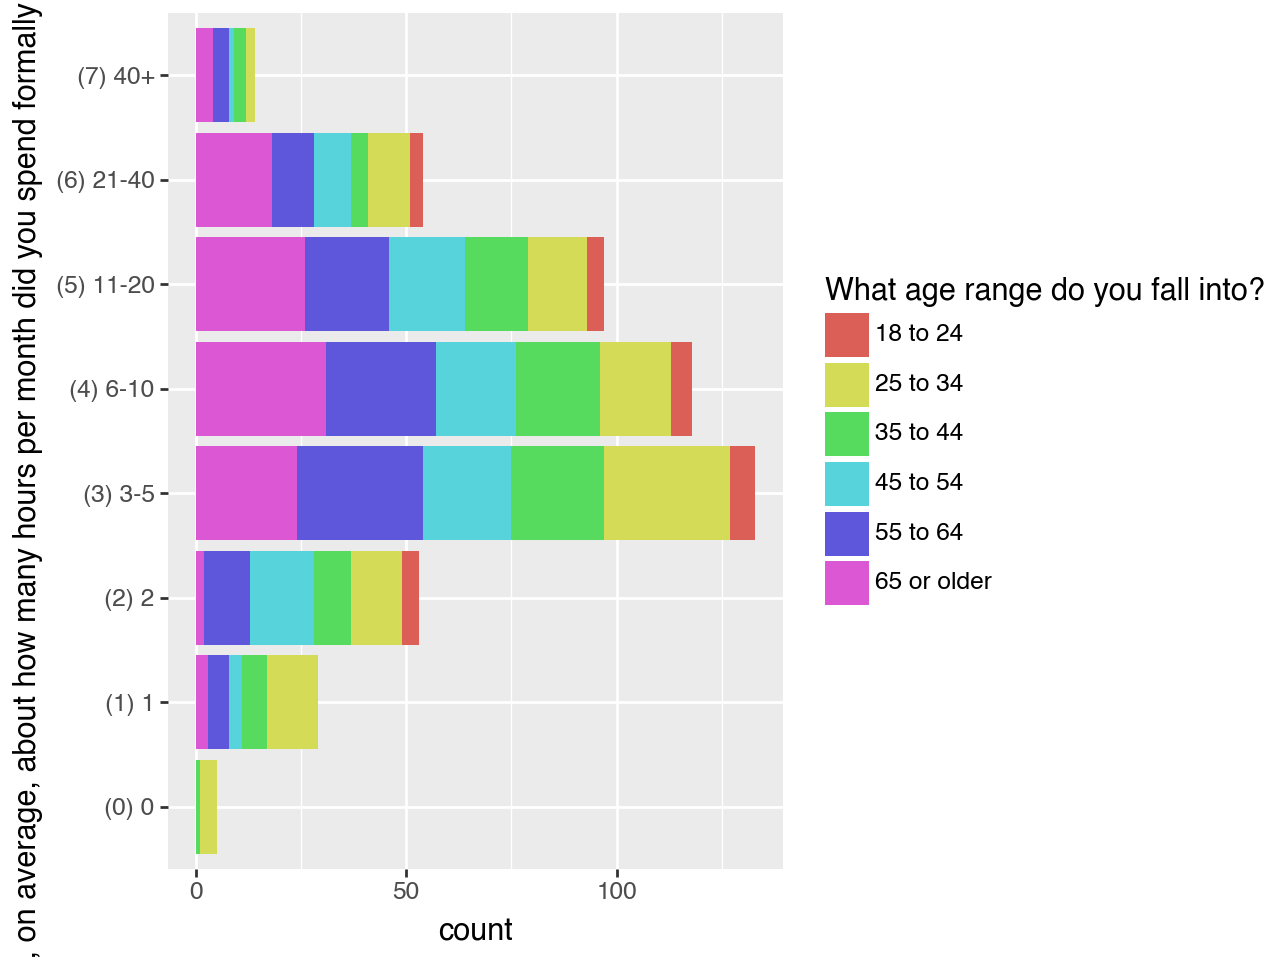

In [29]:
clean_data = volunteerOnline22.dropna(subset=["[Bucketed] In the past 12 months, on average, about how many hours per month did you spend formally volunteering? [Do formal volunteering]"])

(
    ggplot(clean_data)
    + geom_bar(aes(
        x="[Bucketed] In the past 12 months, on average, about how many hours per month did you spend formally volunteering? [Do formal volunteering]",
        fill="What age range do you fall into?"
      ))
    + coord_flip()
)

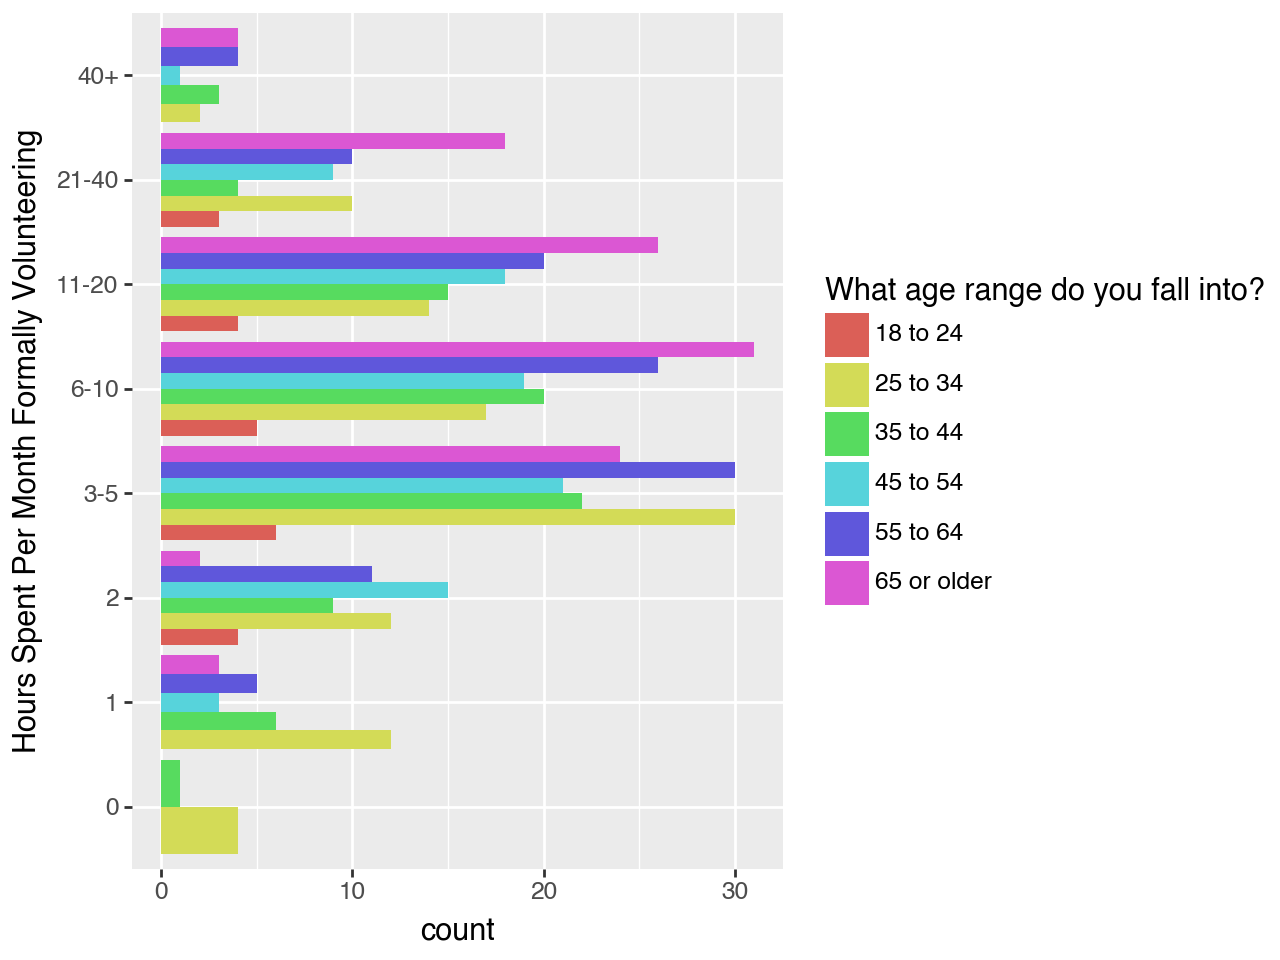

In [30]:
clean_data = volunteerOnline22.dropna(subset=[
    "[Bucketed] In the past 12 months, on average, about how many hours per month did you spend formally volunteering? [Do formal volunteering]"
])
clean_data = clean_data.rename(columns={"[Bucketed] In the past 12 months, on average, about how many hours per month did you spend formally volunteering? [Do formal volunteering]":
                                "Hours Spent Per Month Formally Volunteering"})

clean_data.loc[:,"Hours Spent Per Month Formally Volunteering"] = clean_data.loc[:,"Hours Spent Per Month Formally Volunteering"].replace({
    "(0) 0": "0",
    "(1) 1": "1",
    "(2) 2": "2", 
    "(3) 3-5": "3-5",
    "(4) 6-10": "6-10",
    "(5) 11-20": "11-20",
    "(6) 21-40": "21-40",
    "(7) 40+": "40+"
})

hours_order = ["0", "1", "2", "3-5", "6-10", "11-20", "21-40", "40+"]

clean_data["Hours Spent Per Month Formally Volunteering"] = pd.Categorical(
    clean_data["Hours Spent Per Month Formally Volunteering"],
    categories=hours_order,
    ordered=True
)

(
    ggplot(clean_data)
    + geom_bar(aes(
        x="Hours Spent Per Month Formally Volunteering",
        fill="What age range do you fall into?"
      ),
      position="dodge" 
    )
    + coord_flip()
)


# Volunteering Behaviour Analysis

In [31]:
volunteerColumns = (demographicQuestions+challengesQuestions)
volunteerChallenges = volunteerOnline22[volunteerColumns]

In [32]:
volunteerChallenges.head()

,sample_id,What age range do you fall into?,What is the highest level of education you have completed?,What is your employment status?,"Do you have any children, living at home or that you are a legal guardian for, who are under 18 years old?","Formal volunteering : Which, if any, type(s) of volunteering have you done in the past 12 months?","Opportunities did not match or improve my skill set : Which, if any, challenges have you ever been faced with when volunteering?","Lack of available time : Which, if any, challenges have you ever been faced with when volunteering?","Language Skills : Which, if any, challenges have you ever been faced with when volunteering?","Personal Health : Which, if any, challenges have you ever been faced with when volunteering?",...,"Other challenges : Which, if any, challenges have you ever been faced with when volunteering?","Other challenges : Which, if any, challenges have you ever been faced with when volunteering?","Other challenges : Which, if any, challenges have you ever been faced with when volunteering?","Other challenges : Which, if any, challenges have you ever been faced with when volunteering?","None of the above : Which, if any, challenges have you ever been faced with when volunteering?","I have never volunteered : Which, if any, challenges have you ever been faced with when volunteering?","Other challenges : Which, if any, challenges have you ever been faced with when volunteering?","Other challenges : Which, if any, challenges have you ever been faced with when volunteering?","Other challenges : Which, if any, challenges have you ever been faced with when volunteering?","Other challenges : Which, if any, challenges have you ever been faced with when volunteering?"
0,4668,18 to 24,(6) Graduated university,(5) Student,(0) No,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,NaN,<NA>,NaN,(1) Selected,<NA>,<NA>,NaN,<NA>,NaN
1,3829,25 to 34,(6) Graduated university,(1) Working full-time,(0) No,<NA>,<NA>,(1) Selected,<NA>,<NA>,...,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>,NaN,<NA>,NaN
2,4119,18 to 24,"(4) Graduated college, apprenticeship or trades",(1) Working full-time,(0) No,(-8) Refused,<NA>,<NA>,<NA>,<NA>,...,<NA>,NaN,<NA>,NaN,(1) Selected,<NA>,<NA>,NaN,<NA>,NaN
3,2091,18 to 24,(1) Not graduated from high school,(4) Unemployed,(0) No,<NA>,(1) Selected,<NA>,<NA>,(1) Selected,...,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>,NaN,<NA>,NaN
4,3855,18 to 24,(5) Some university,(2) Working part-time,(0) No,(1) Selected,<NA>,<NA>,<NA>,<NA>,...,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>,NaN,<NA>,NaN


# Challenge Analysis

In [33]:
volunteerChallenges.describe(exclude=[np.number])

,What age range do you fall into?,What is the highest level of education you have completed?,What is your employment status?,"Do you have any children, living at home or that you are a legal guardian for, who are under 18 years old?","Formal volunteering : Which, if any, type(s) of volunteering have you done in the past 12 months?","Opportunities did not match or improve my skill set : Which, if any, challenges have you ever been faced with when volunteering?","Lack of available time : Which, if any, challenges have you ever been faced with when volunteering?","Language Skills : Which, if any, challenges have you ever been faced with when volunteering?","Personal Health : Which, if any, challenges have you ever been faced with when volunteering?","Age : Which, if any, challenges have you ever been faced with when volunteering?",...,"Other challenges : Which, if any, challenges have you ever been faced with when volunteering?","Other challenges : Which, if any, challenges have you ever been faced with when volunteering?","Other challenges : Which, if any, challenges have you ever been faced with when volunteering?","Other challenges : Which, if any, challenges have you ever been faced with when volunteering?","None of the above : Which, if any, challenges have you ever been faced with when volunteering?","I have never volunteered : Which, if any, challenges have you ever been faced with when volunteering?","Other challenges : Which, if any, challenges have you ever been faced with when volunteering?","Other challenges : Which, if any, challenges have you ever been faced with when volunteering?","Other challenges : Which, if any, challenges have you ever been faced with when volunteering?","Other challenges : Which, if any, challenges have you ever been faced with when volunteering?"
count,1564,1538,1538,1550,612,106,572,24,178,73,...,17,61,17,61,348,119,17,61,17,61
unique,6,6,7,2,2,1,1,1,1,1,...,1,61,1,61,1,1,1,61,1,61
top,25 to 34,(6) Graduated university,(1) Working full-time,(0) No,(1) Selected,(1) Selected,(1) Selected,(1) Selected,(1) Selected,(1) Selected,...,(1) Selected,"Where I was doing volunteer, the ground condit...",(1) Selected,"Where I was doing volunteer, the ground condit...",(1) Selected,(1) Selected,(1) Selected,"Where I was doing volunteer, the ground condit...",(1) Selected,"Where I was doing volunteer, the ground condit..."
freq,336,689,750,1190,591,106,572,24,178,73,...,17,1,17,1,348,119,17,1,17,1


In [34]:
seniorChallenges = volunteerChallenges[
    volunteerChallenges["What age range do you fall into?"].isin(["65 or older", "55 to 64"])
].drop(['Other challenges : Which, if any, challenges have you ever been faced with when volunteering?'],axis=1)

In [35]:
seniorChallenges.describe(exclude=[np.number])

,What age range do you fall into?,What is the highest level of education you have completed?,What is your employment status?,"Do you have any children, living at home or that you are a legal guardian for, who are under 18 years old?","Formal volunteering : Which, if any, type(s) of volunteering have you done in the past 12 months?","Opportunities did not match or improve my skill set : Which, if any, challenges have you ever been faced with when volunteering?","Lack of available time : Which, if any, challenges have you ever been faced with when volunteering?","Language Skills : Which, if any, challenges have you ever been faced with when volunteering?","Personal Health : Which, if any, challenges have you ever been faced with when volunteering?","Age : Which, if any, challenges have you ever been faced with when volunteering?",...,"Lack of flexible scheduling : Which, if any, challenges have you ever been faced with when volunteering?","Lack of support for volunteering at different locations : Which, if any, challenges have you ever been faced with when volunteering?","Did not accommodate groups or families : Which, if any, challenges have you ever been faced with when volunteering?","Did not offer accommodations to those with health issues : Which, if any, challenges have you ever been faced with when volunteering?","Did not appear to be welcoming and inclusive to all Albertans : Which, if any, challenges have you ever been faced with when volunteering?","Unclear or unreasonable expectations : Which, if any, challenges have you ever been faced with when volunteering?","Volunteer recruitment or interview processes : Which, if any, challenges have you ever been faced with when volunteering?","Required too much or too little of my time : Which, if any, challenges have you ever been faced with when volunteering?","None of the above : Which, if any, challenges have you ever been faced with when volunteering?","I have never volunteered : Which, if any, challenges have you ever been faced with when volunteering?"
count,646,636,638,642,246,34,162,8,82,59,...,53,23,5,7,17,51,28,91,187,44
unique,2,6,7,2,2,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
top,55 to 64,(6) Graduated university,(6) Retired,(0) No,(1) Selected,(1) Selected,(1) Selected,(1) Selected,(1) Selected,(1) Selected,...,(1) Selected,(1) Selected,(1) Selected,(1) Selected,(1) Selected,(1) Selected,(1) Selected,(1) Selected,(1) Selected,(1) Selected
freq,325,253,327,604,240,34,162,8,82,59,...,53,23,5,7,17,51,28,91,187,44


In [36]:
nonSeniorChallenges = volunteerChallenges[
    volunteerChallenges["What age range do you fall into?"].isin(["25 to 34","35 to 44","45 to 54","18 to 24"])
].drop(['Other challenges : Which, if any, challenges have you ever been faced with when volunteering?'],axis=1)


In [37]:
nonSeniorChallenges.describe(exclude=[np.number])

,What age range do you fall into?,What is the highest level of education you have completed?,What is your employment status?,"Do you have any children, living at home or that you are a legal guardian for, who are under 18 years old?","Formal volunteering : Which, if any, type(s) of volunteering have you done in the past 12 months?","Opportunities did not match or improve my skill set : Which, if any, challenges have you ever been faced with when volunteering?","Lack of available time : Which, if any, challenges have you ever been faced with when volunteering?","Language Skills : Which, if any, challenges have you ever been faced with when volunteering?","Personal Health : Which, if any, challenges have you ever been faced with when volunteering?","Age : Which, if any, challenges have you ever been faced with when volunteering?",...,"Lack of flexible scheduling : Which, if any, challenges have you ever been faced with when volunteering?","Lack of support for volunteering at different locations : Which, if any, challenges have you ever been faced with when volunteering?","Did not accommodate groups or families : Which, if any, challenges have you ever been faced with when volunteering?","Did not offer accommodations to those with health issues : Which, if any, challenges have you ever been faced with when volunteering?","Did not appear to be welcoming and inclusive to all Albertans : Which, if any, challenges have you ever been faced with when volunteering?","Unclear or unreasonable expectations : Which, if any, challenges have you ever been faced with when volunteering?","Volunteer recruitment or interview processes : Which, if any, challenges have you ever been faced with when volunteering?","Required too much or too little of my time : Which, if any, challenges have you ever been faced with when volunteering?","None of the above : Which, if any, challenges have you ever been faced with when volunteering?","I have never volunteered : Which, if any, challenges have you ever been faced with when volunteering?"
count,918,902,900,908,366,72,410,16,96,14,...,139,43,28,24,47,105,65,186,161,75
unique,4,6,7,2,2,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
top,25 to 34,(6) Graduated university,(1) Working full-time,(0) No,(1) Selected,(1) Selected,(1) Selected,(1) Selected,(1) Selected,(1) Selected,...,(1) Selected,(1) Selected,(1) Selected,(1) Selected,(1) Selected,(1) Selected,(1) Selected,(1) Selected,(1) Selected,(1) Selected
freq,336,436,581,586,351,72,410,16,96,14,...,139,43,28,24,47,105,65,186,161,75


# Volunteer To What Extent

In [38]:
toWhatExtentList = (demographicQuestions+toWhatExtentQuestions)
volunteerToWhatExtent = volunteerOnline22[toWhatExtentList]

In [39]:
volunteerToWhatExtentCounts = volunteerToWhatExtent.describe(exclude = [np.number])
volunteerToWhatExtentCounts.sort_values(by='freq',axis=1,ascending=False)

,"Do you have any children, living at home or that you are a legal guardian for, who are under 18 years old?",Volunteering is for people of all ages. : To what extent do you agree with the following statements?,"Whether large or small, all contributions by volunteers make a positive difference in the community. : To what extent do you agree with the following statements?",Provides an opportunity to give back to the community/make the community a better place to live. : To what extent do you agree that each of the following are benefits of volunteering?,Volunteers are important contributors to Alberta's economy. : To what extent do you agree with the following statements?,Provides an opportunity to make meaningful connections with people. : To what extent do you agree that each of the following are benefits of volunteering?,What is your employment status?,Supports your own physical and/or mental health and wellness. : To what extent do you agree that each of the following are benefits of volunteering?,What is the highest level of education you have completed?,"Formal volunteering : Which, if any, type(s) of volunteering have you done in the past 12 months?",Organizations that are welcoming and inclusive to all Albertans. : To what extent would each of the following make formal volunteering more appealing for you?,Access to volunteer opportunities that offer flexible schedules. : To what extent would each of the following make formal volunteering more appealing for you?,Organizations that understand and work to meet the needs of my community. : To what extent would each of the following make formal volunteering more appealing for you?,Organizations that regularly recognize the contributions of volunteers. : To what extent would each of the following make formal volunteering more appealing for you?,Access to volunteer opportunities that offer training with current technology : To what extent would each of the following make formal volunteering more appealing for you?,Access to volunteer opportunities that match and help improve my skill set. : To what extent would each of the following make formal volunteering more appealing for you?,Organizations that support different ways of volunteering : To what extent would each of the following make formal volunteering more appealing for you?,Organizations that support group or family volunteering opportunities. : To what extent would each of the following make formal volunteering more appealing for you?,What age range do you fall into?
count,1550,1546,1542,1541,1498,1532,1538,1514,1538,612,1411,1431,1460,1456,1439,1387,1452,1429,1564
unique,2,4,4,4,4,4,7,4,6,2,4,4,4,4,4,4,4,4,6
top,(0) No,(4) Strongly agree,(4) Strongly agree,(4) Strongly agree,(4) Strongly agree,(4) Strongly agree,(1) Working full-time,(4) Strongly agree,(6) Graduated university,(1) Selected,(4) A lot more appealing,(4) A lot more appealing,(4) A lot more appealing,(1) Not at all,(1) Not at all,(3) Moderately more appealing,(3) Moderately more appealing,(1) Not at all,25 to 34
freq,1190,1095,1058,999,871,831,750,747,689,591,487,485,461,456,447,432,418,397,336


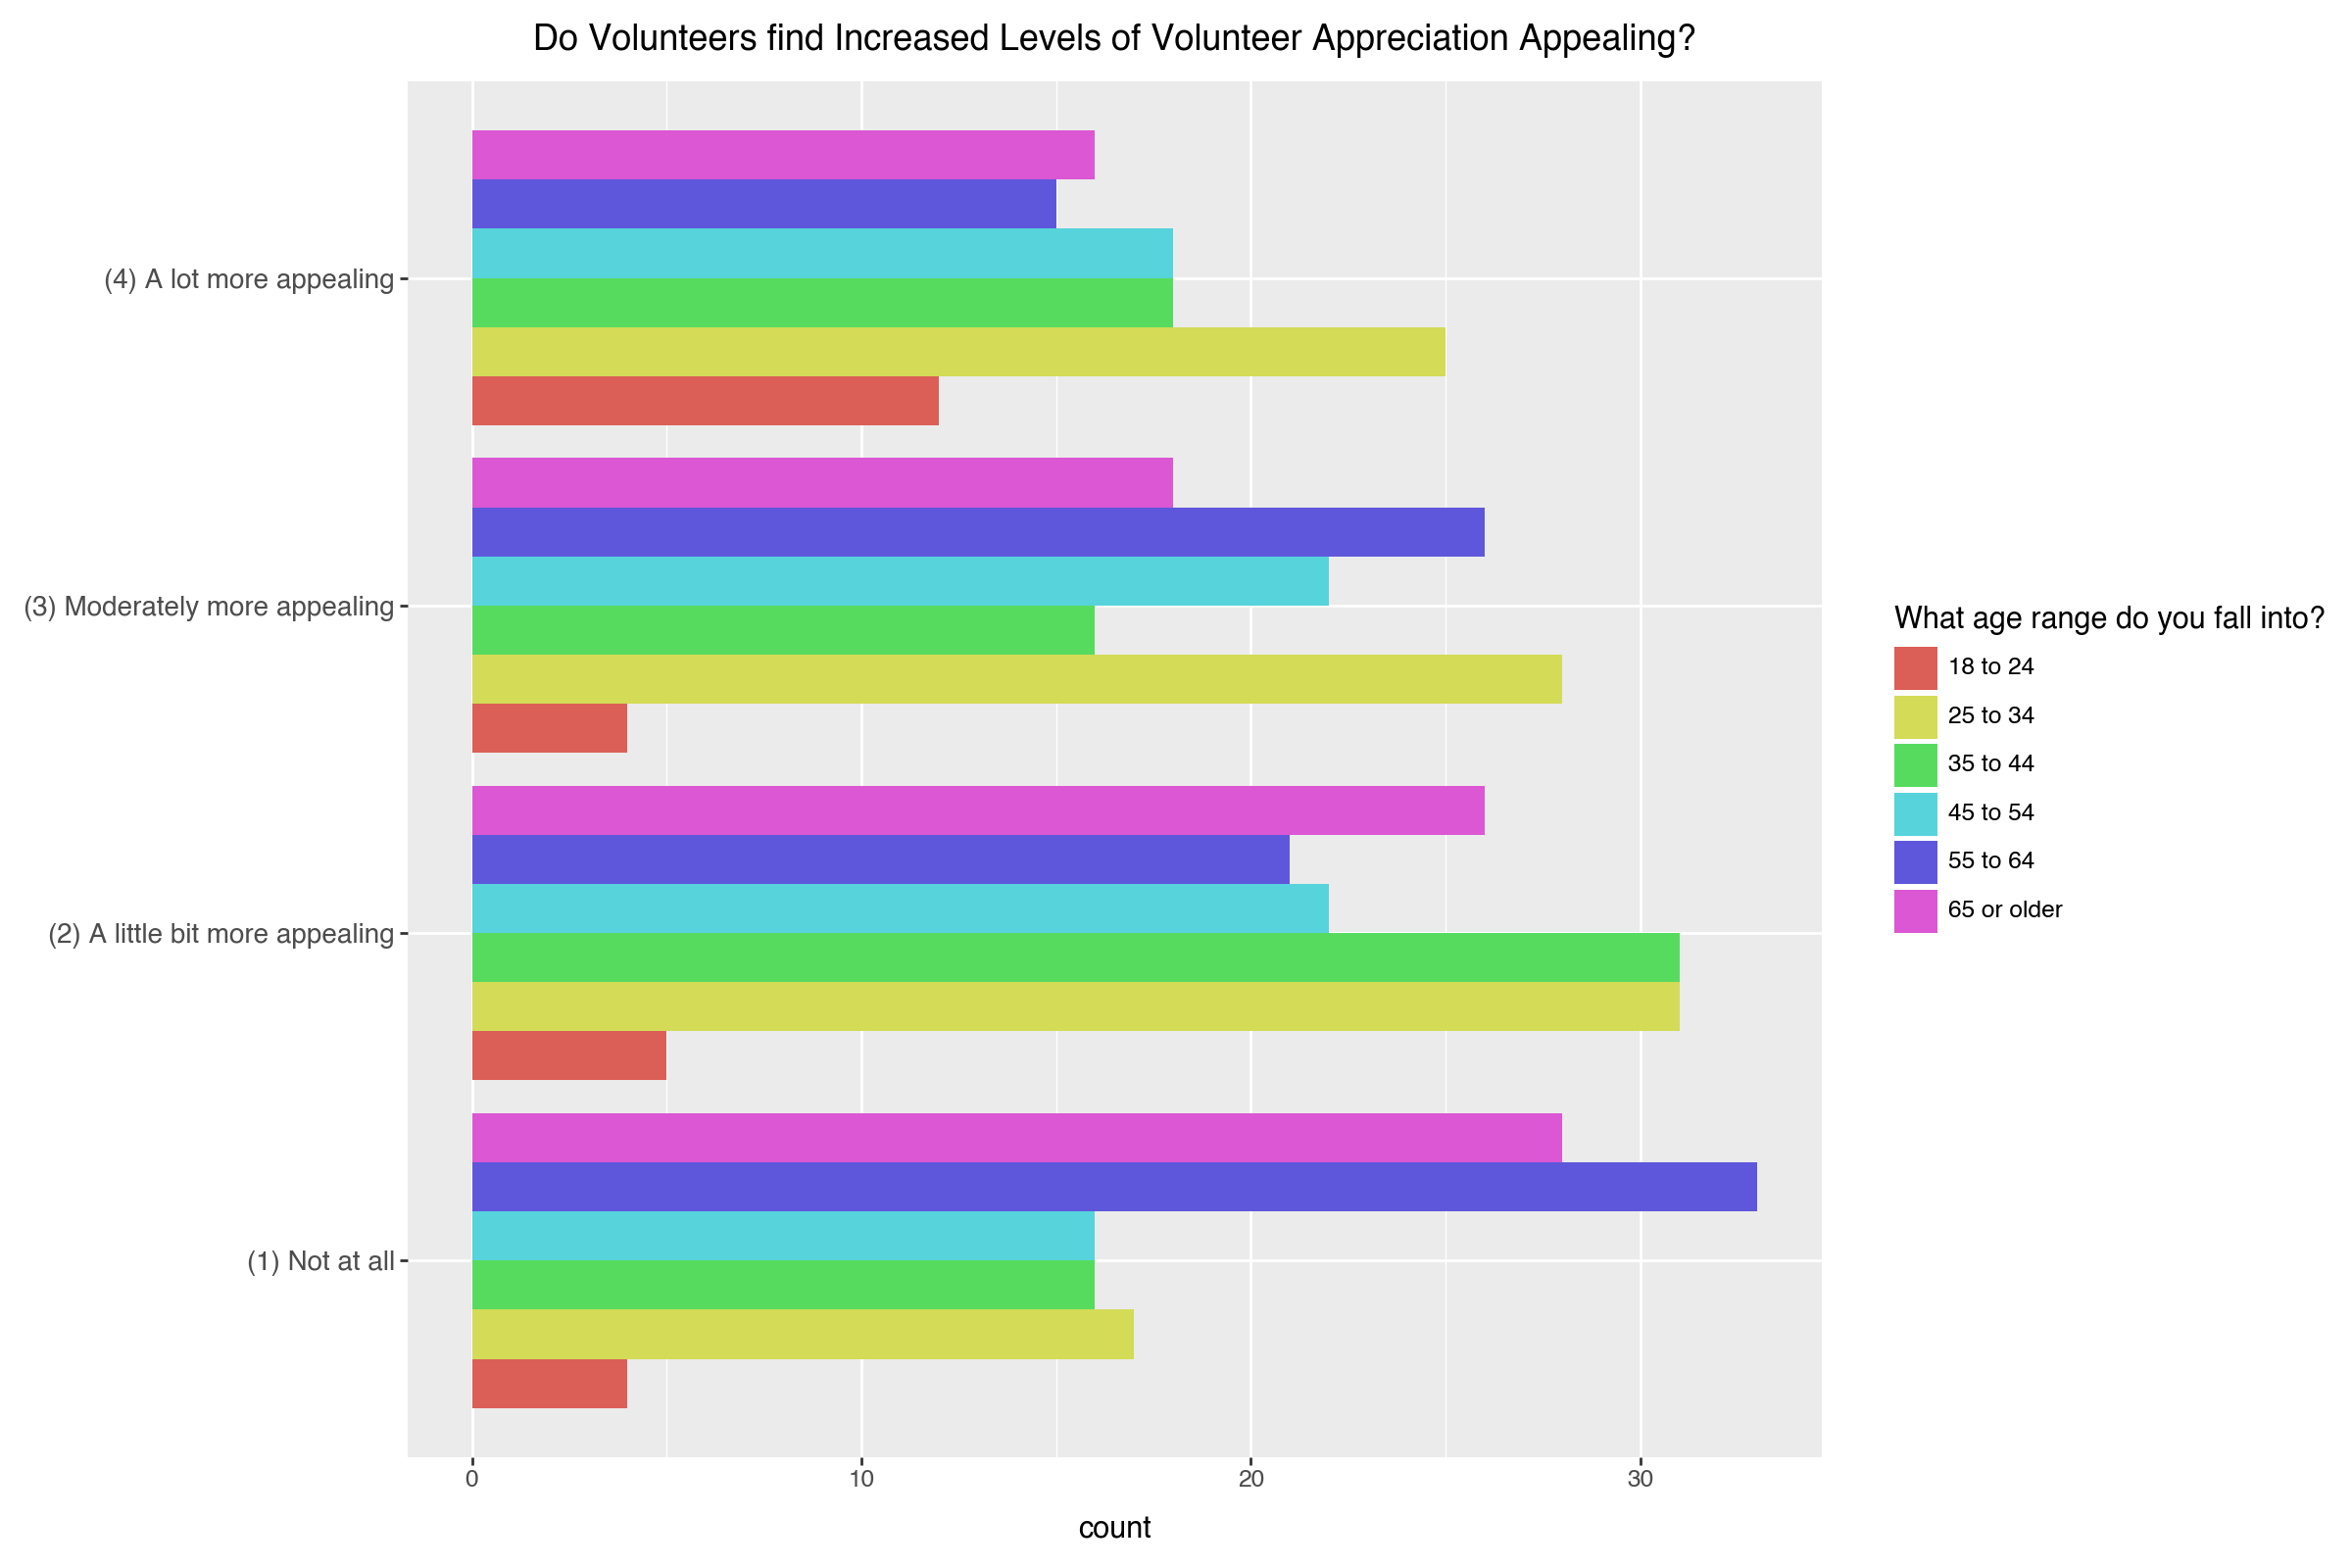

In [51]:
chosenValue = "Organizations that regularly recognize the contributions of volunteers. : To what extent would each of the following make formal volunteering more appealing for you?"
volunteerToWhatExtent.rename({chosenValue: "response"})
(
    ggplot(volunteerToWhatExtent.dropna())
    + geom_bar(aes(
        x=chosenValue,fill= "What age range do you fall into?"
      ), position = 'dodge')
    + coord_flip()
    + xlab("")
    + labs(title = "Do Volunteers find Increased Levels of Volunteer Appreciation Appealing?")     + theme(
     figure_size=(12, 8),  # Increase overall plot size
     plot_title=element_text(size=13, wrap=True),  # Increase title size and enable wrapping
     axis_text_y=element_text(size=10)  # Increase y-axis text size (which is your categories after flip)
 )
)

In [52]:
volunteerToWhatExtent = volunteerToWhatExtent[volunteerToWhatExtent["Hours Spent Per Month Formally Volunteering"].str.contains("0", na=False)]

KeyError: 'Hours Spent Per Month Formally Volunteering'

In [53]:
volunteerToWhatExtent["Organizations that regularly recognize the contributions of volunteers. : To what extent would each of the following make formal volunteering more appealing for you?"].value_counts()

Organizations that regularly recognize the contributions of volunteers. : To what extent would each of the following make formal volunteering more appealing for you?
(1) Not at all                     456
(2) A little bit more appealing    397
(3) Moderately more appealing      323
(4) A lot more appealing           280
Name: count, dtype: int64

In [54]:
#volunteertoWhatExtent[volunteertoWhatExtent["Formal volunteering : Which, if any, type(s) of volunteering have you done in the past 12 months?"] == ]
volunteer = clean_data[clean_data["Hours Spent Per Month Formally Volunteering"].str.contains("0", na=False)]
volunteer["Organizations that regularly recognize the contributions of volunteers. : To what extent would each of the following make formal volunteering more appealing for you?"].value_counts()
#volunteer["Hours Spent Per Month Formally Volunteering"].value_counts()


Organizations that regularly recognize the contributions of volunteers. : To what extent would each of the following make formal volunteering more appealing for you?
(2) A little bit more appealing    78
(1) Not at all                     70
(3) Moderately more appealing      69
(4) A lot more appealing           63
Name: count, dtype: int64

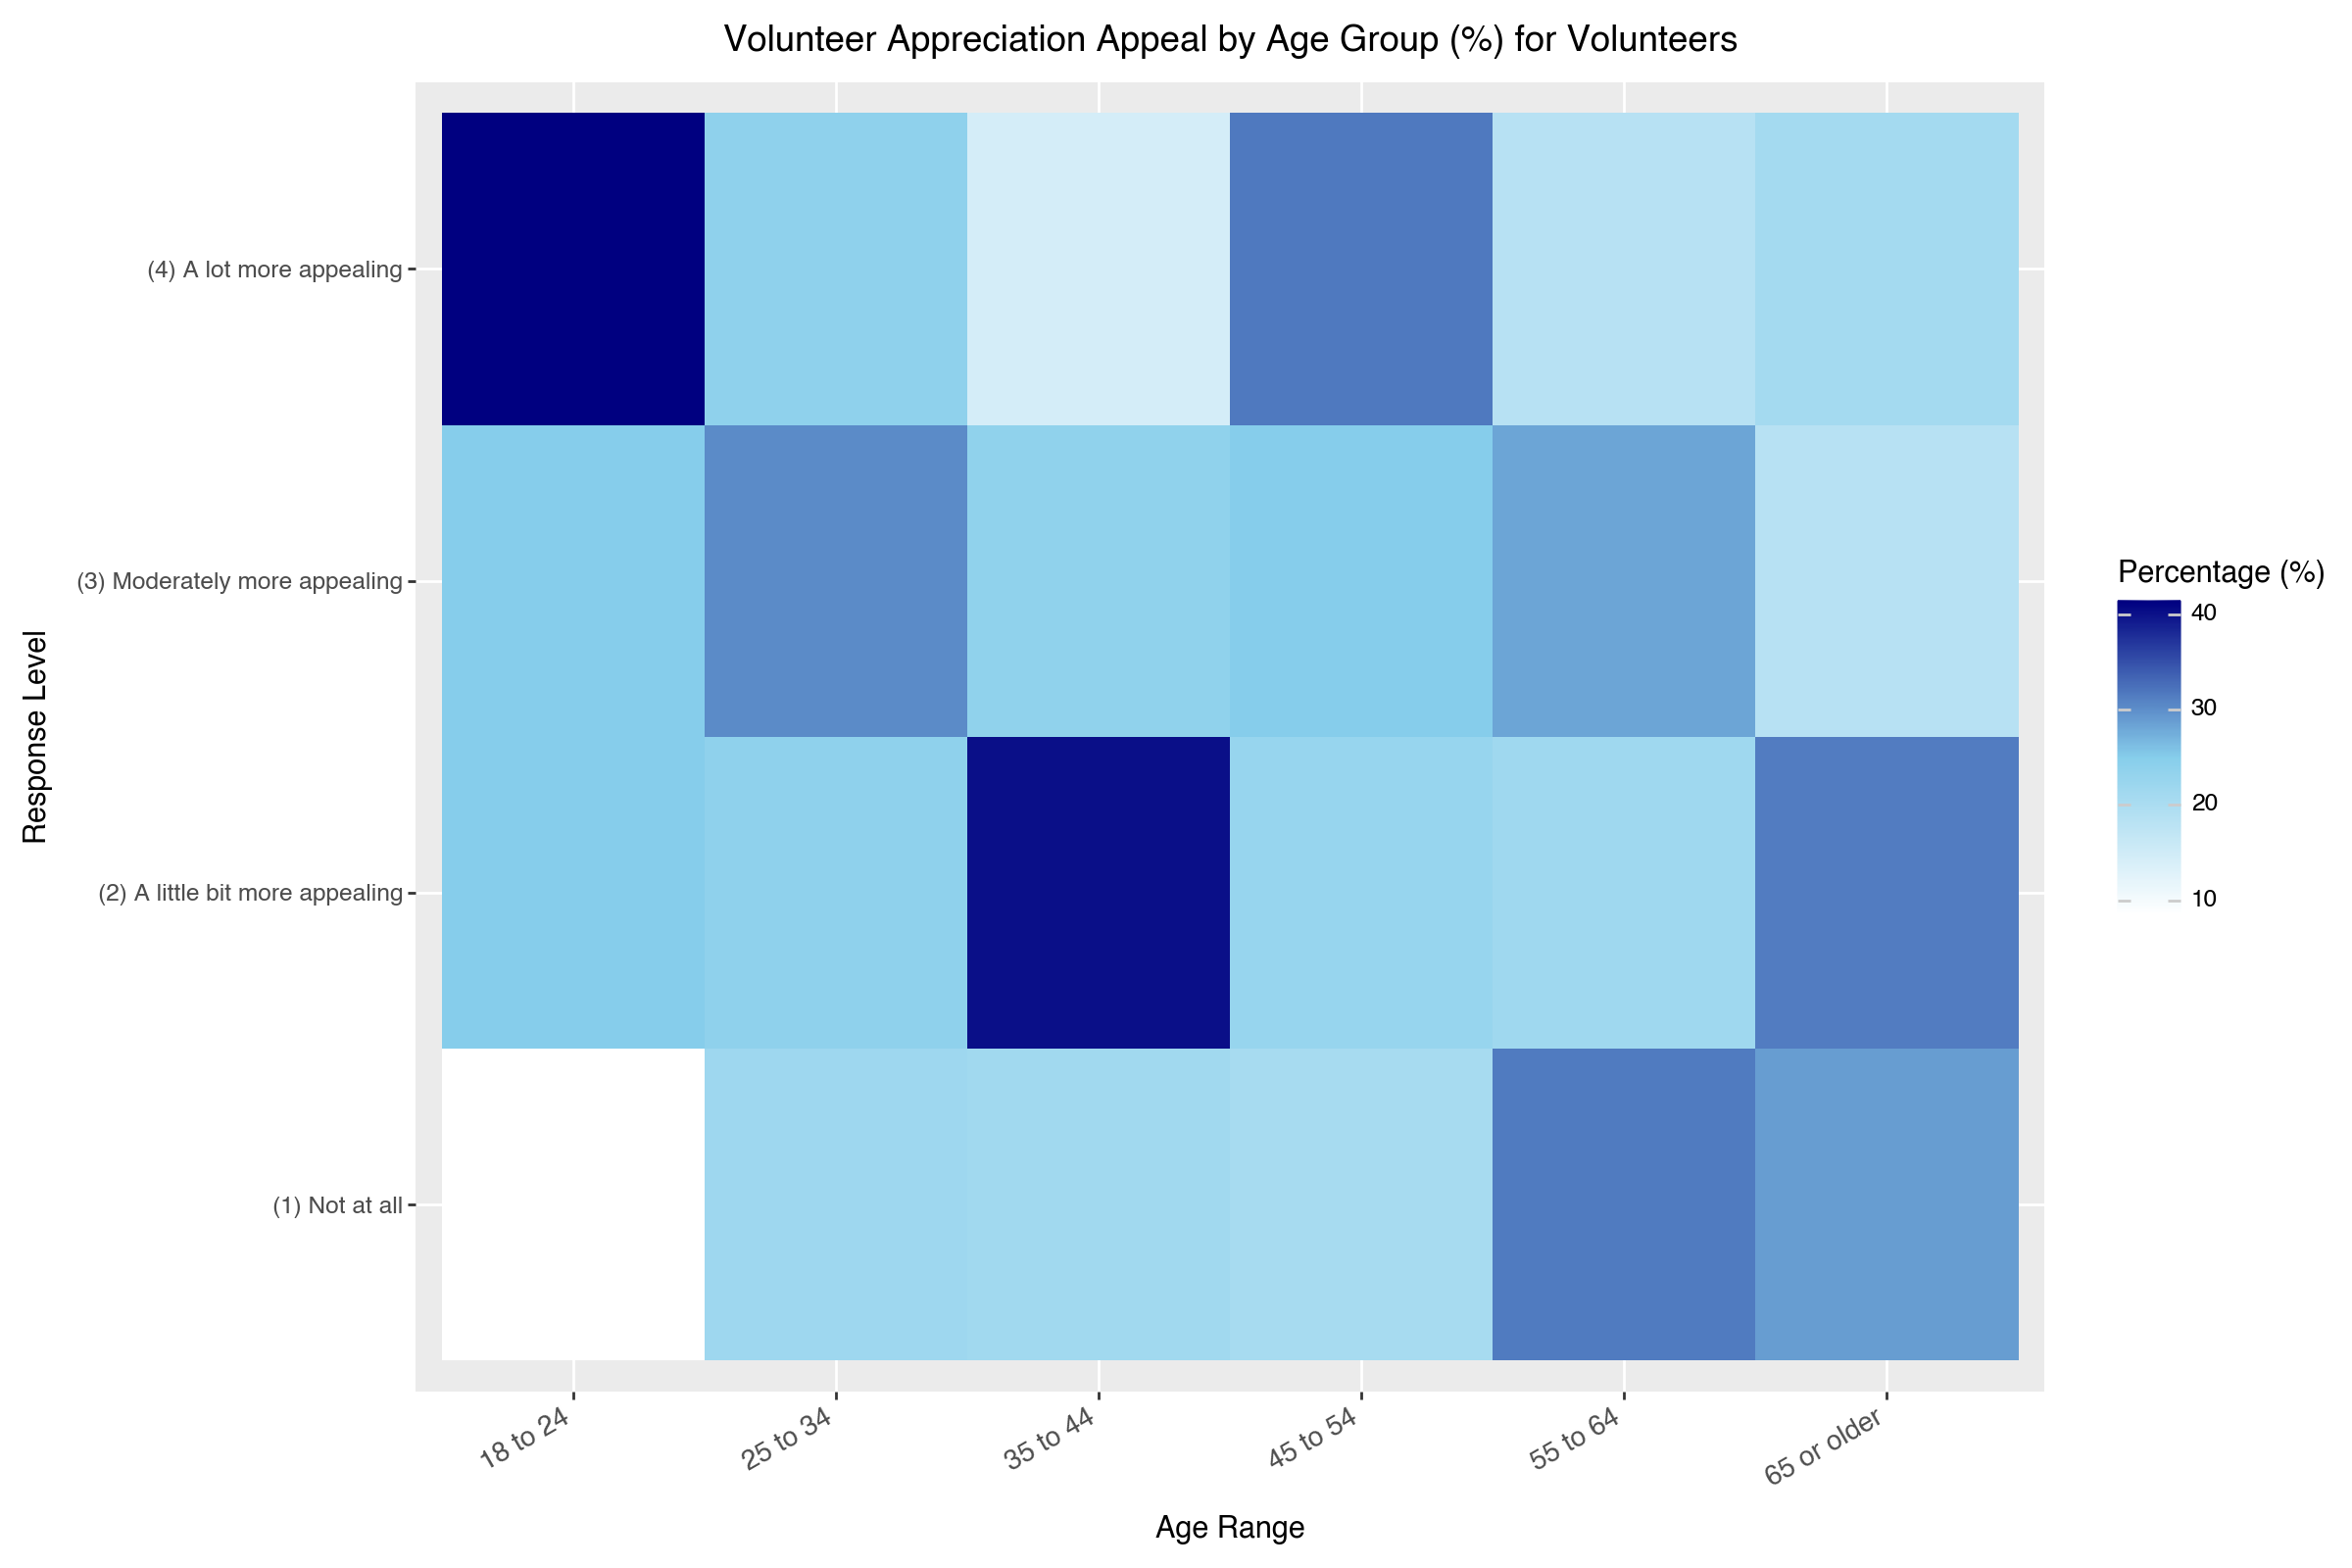

In [55]:

crosstab = pd.crosstab(
    index=volunteer["What age range do you fall into?"],
    columns=volunteer[chosenValue],
    normalize='index'  # This normalizes by row (age group) to get percentages
) * 100  # Multiply by 100 to get actual percentages instead of proportions

# Convert to long format for plotting
plot_data = crosstab.reset_index().melt(
    id_vars="What age range do you fall into?",
    var_name="response",
    value_name="percentage"
)
(
    ggplot(plot_data, 
           aes(x="What age range do you fall into?", 
               y="response", 
               fill="percentage"))
    + geom_tile()
    + theme(figure_size=(12, 8),
            axis_text_x=element_text(angle=45, hjust=1))
    + labs(title="Volunteer Appreciation Appeal by Age Group (%) for Volunteers",
           x="Age Range",
           y="Response Level",
           fill="Percentage (%)")
    + theme(axis_text_x=element_text(angle=30, hjust=1, size=10))
    + scale_fill_gradient2(low="white", mid="skyblue", high="navy", midpoint=25)
)


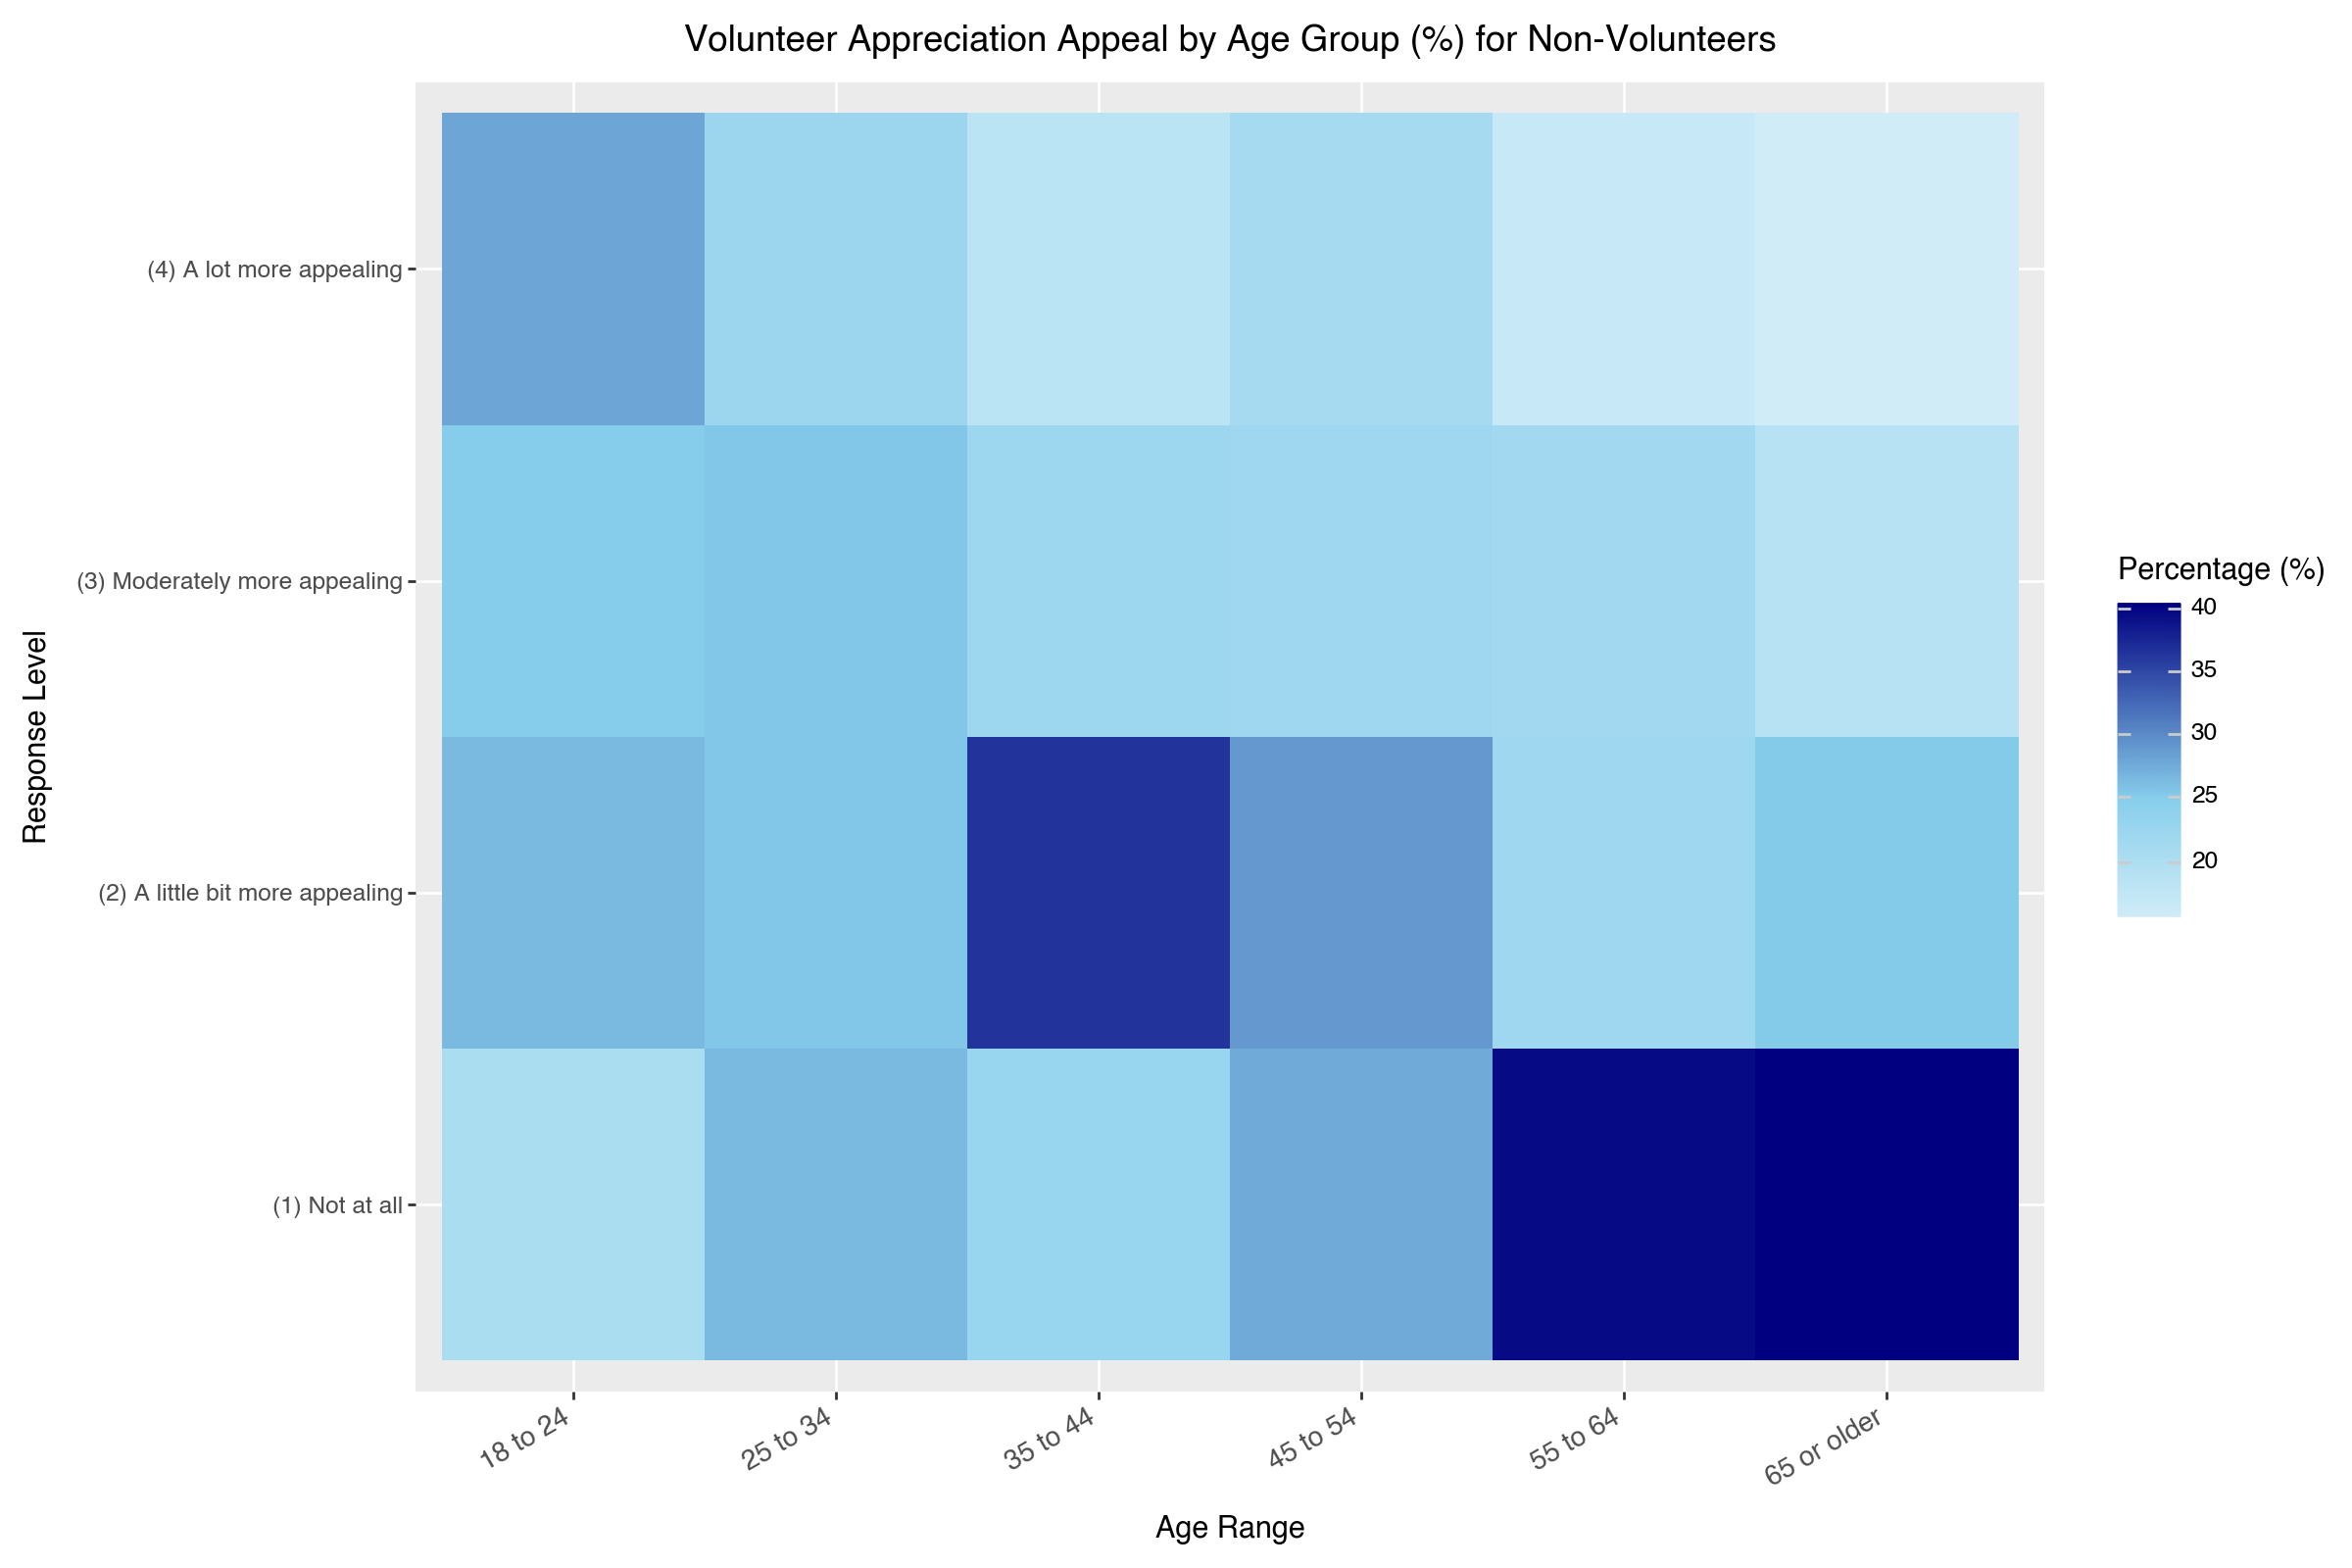

In [56]:

crosstab = pd.crosstab(
    index=volunteerToWhatExtent["What age range do you fall into?"],
    columns=volunteerToWhatExtent[chosenValue],
    normalize='index'  # This normalizes by row (age group) to get percentages
) * 100  # Multiply by 100 to get actual percentages instead of proportions

# Convert to long format for plotting
plot_data = crosstab.reset_index().melt(
    id_vars="What age range do you fall into?",
    var_name="response",
    value_name="percentage"
)
(
    ggplot(plot_data, 
           aes(x="What age range do you fall into?", 
               y="response", 
               fill="percentage"))
    + geom_tile()
    + theme(figure_size=(12, 8),
            axis_text_x=element_text(angle=45, hjust=1))
    + labs(title="Volunteer Appreciation Appeal by Age Group (%) for Non-Volunteers",
           x="Age Range",
           y="Response Level",
           fill="Percentage (%)")
    + theme(axis_text_x=element_text(angle=30, hjust=1, size=10))
    + scale_fill_gradient2(low="white", mid="skyblue", high="navy", midpoint=25)
)


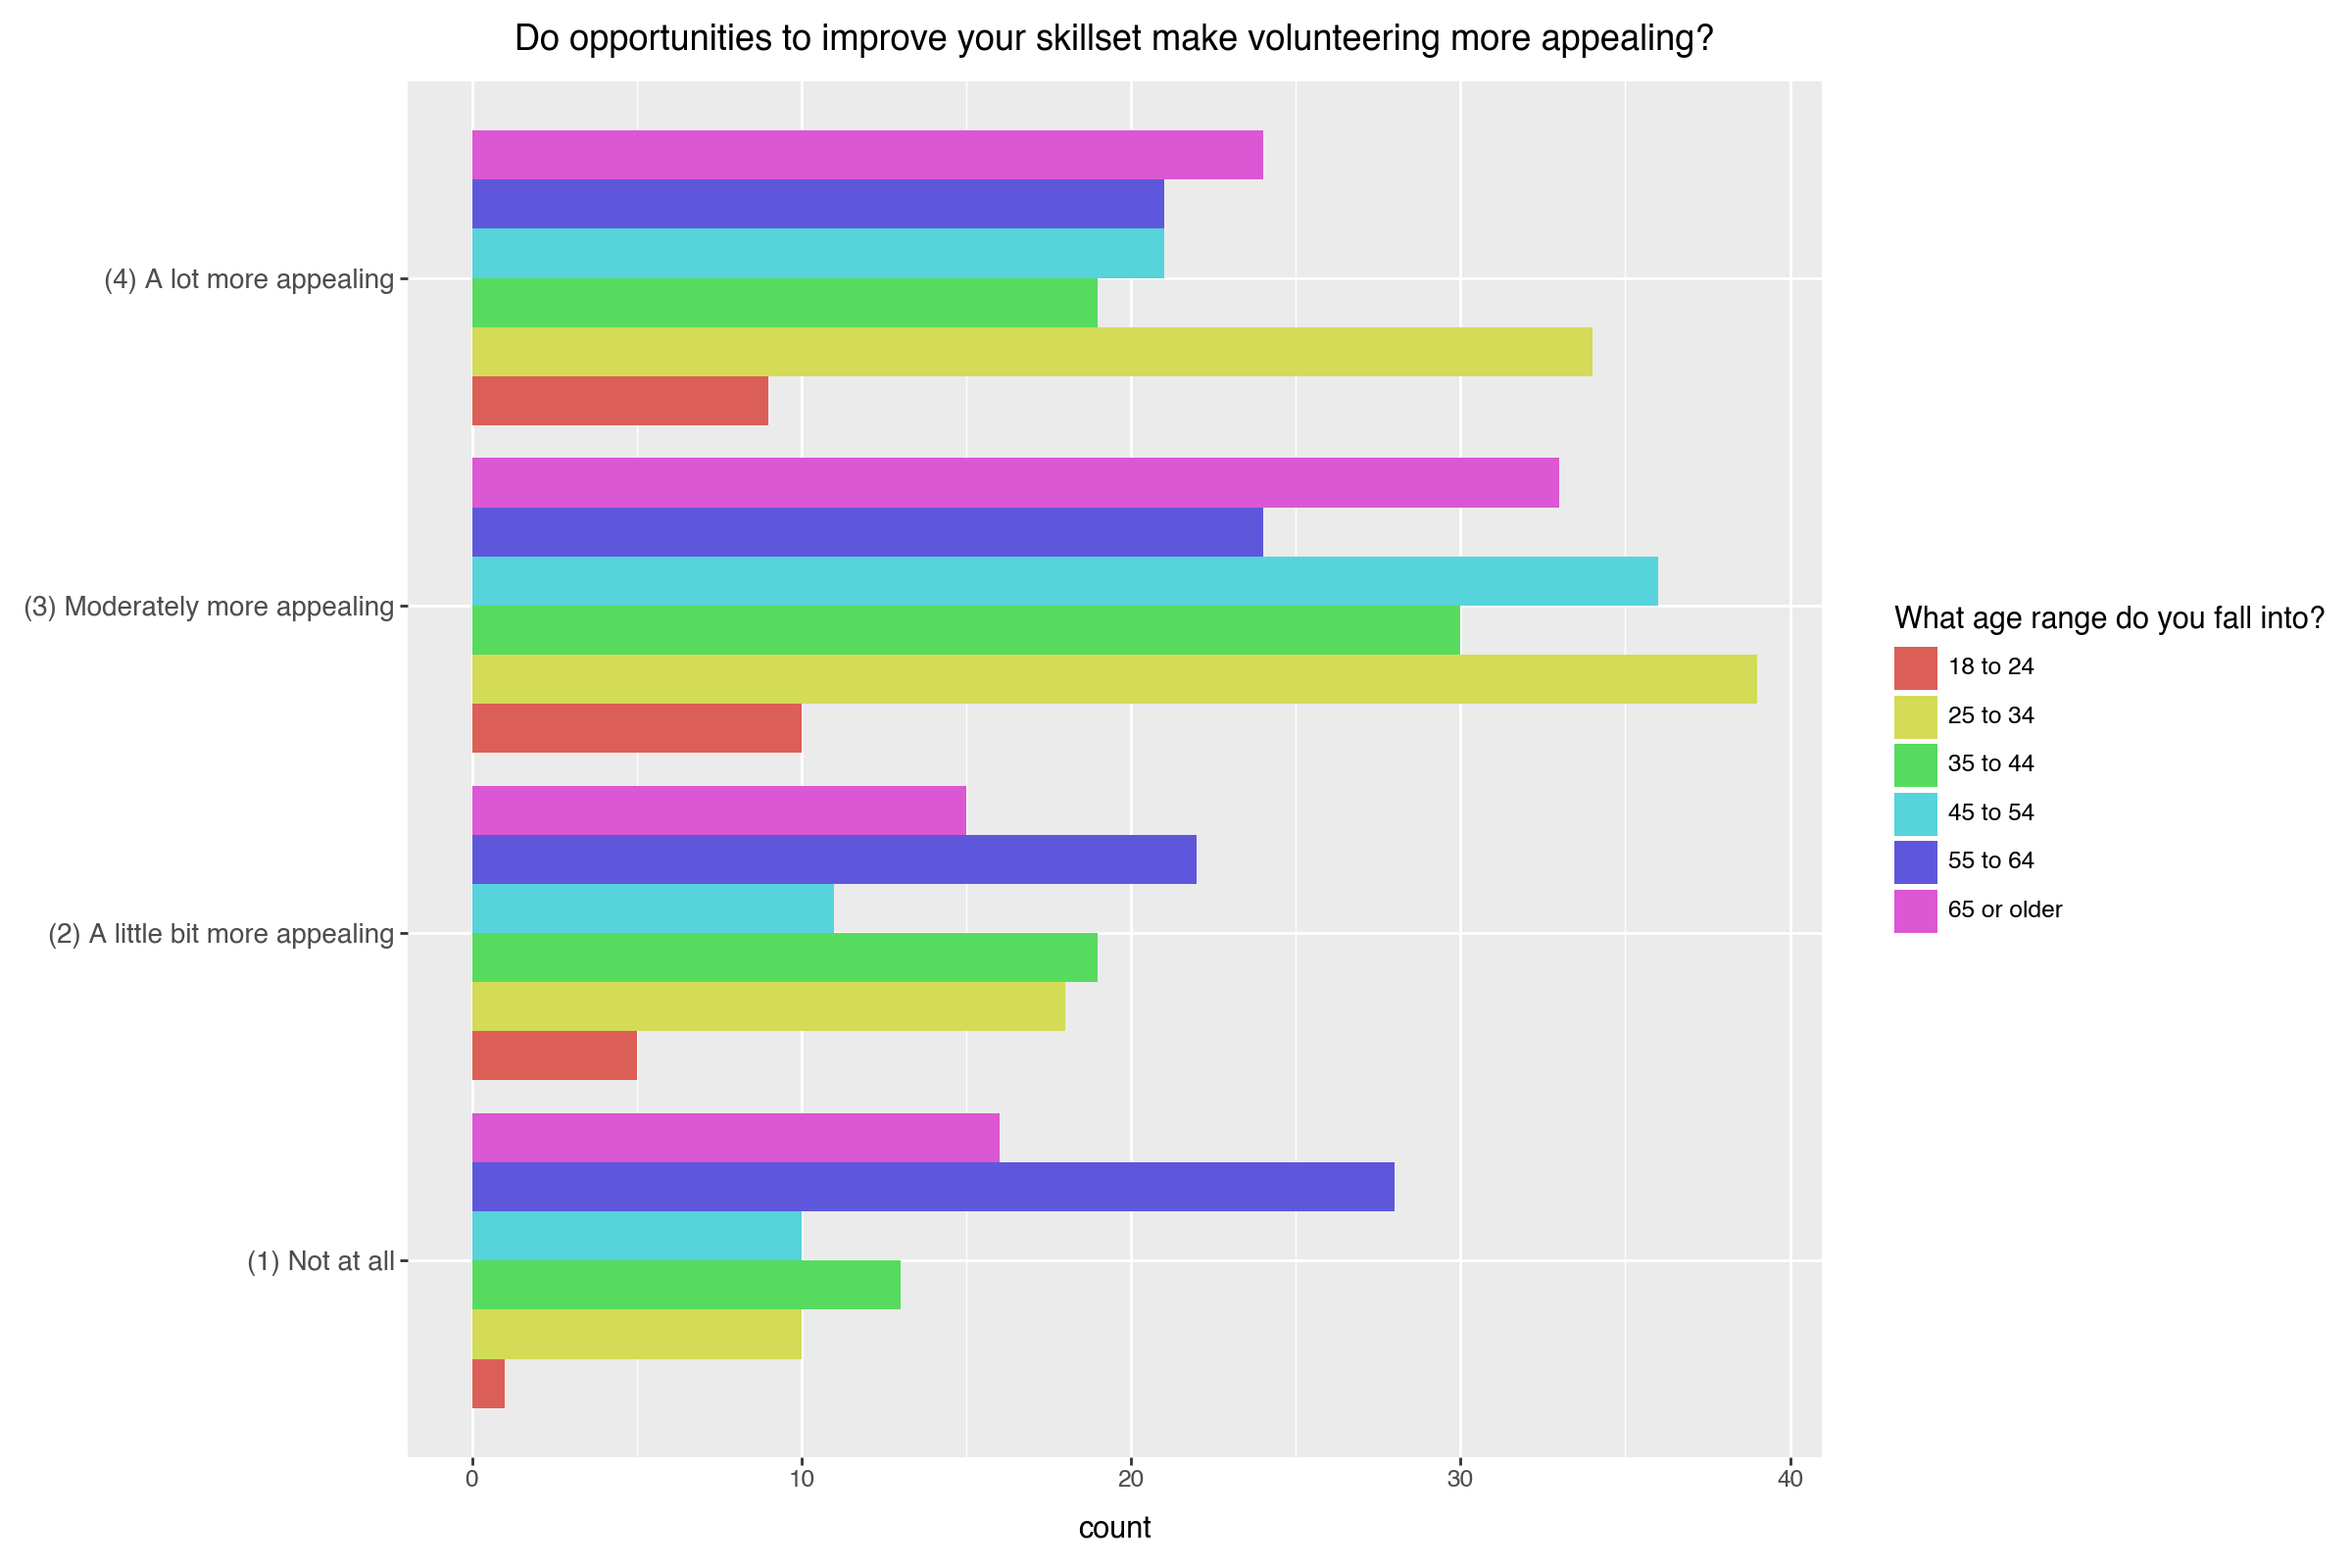

In [57]:
chosenValue = "Access to volunteer opportunities that match and help improve my skill set. : To what extent would each of the following make formal volunteering more appealing for you?"
volunteerToWhatExtent.rename({chosenValue: "response"})
(
    ggplot(volunteerToWhatExtent.dropna())
    + geom_bar(aes(
        x=chosenValue,fill= "What age range do you fall into?"
      ), position = 'dodge')
    + coord_flip()
    + xlab("")
    + labs(title = "Do opportunities to improve your skillset make volunteering more appealing?")
     + theme(
     figure_size=(12, 8),  # Increase overall plot size
     plot_title=element_text(size=13, wrap=True),  # Increase title size and enable wrapping
     axis_text_y=element_text(size=10)  # Increase y-axis text size (which is your categories after flip)
 )
)

## Senior-Related

In [58]:
nonSeniorToWhatExtent = volunteerToWhatExtent[
    volunteerToWhatExtent["What age range do you fall into?"].isin(["25 to 34","35 to 44","45 to 54","18 to 24"])]

In [59]:
nonSeniorToWhatExtentCounts = nonSeniorToWhatExtent.describe(exclude = [np.number])
nonSeniorToWhatExtentCounts.sort_values(by='freq',axis=1,ascending=False)

,Volunteering is for people of all ages. : To what extent do you agree with the following statements?,"Whether large or small, all contributions by volunteers make a positive difference in the community. : To what extent do you agree with the following statements?","Do you have any children, living at home or that you are a legal guardian for, who are under 18 years old?",What is your employment status?,Provides an opportunity to give back to the community/make the community a better place to live. : To what extent do you agree that each of the following are benefits of volunteering?,Provides an opportunity to make meaningful connections with people. : To what extent do you agree that each of the following are benefits of volunteering?,What is the highest level of education you have completed?,Volunteers are important contributors to Alberta's economy. : To what extent do you agree with the following statements?,Supports your own physical and/or mental health and wellness. : To what extent do you agree that each of the following are benefits of volunteering?,"Formal volunteering : Which, if any, type(s) of volunteering have you done in the past 12 months?",Access to volunteer opportunities that offer flexible schedules. : To what extent would each of the following make formal volunteering more appealing for you?,What age range do you fall into?,Organizations that are welcoming and inclusive to all Albertans. : To what extent would each of the following make formal volunteering more appealing for you?,Organizations that understand and work to meet the needs of my community. : To what extent would each of the following make formal volunteering more appealing for you?,Access to volunteer opportunities that match and help improve my skill set. : To what extent would each of the following make formal volunteering more appealing for you?,Organizations that support different ways of volunteering : To what extent would each of the following make formal volunteering more appealing for you?,Organizations that regularly recognize the contributions of volunteers. : To what extent would each of the following make formal volunteering more appealing for you?,Organizations that support group or family volunteering opportunities. : To what extent would each of the following make formal volunteering more appealing for you?,Access to volunteer opportunities that offer training with current technology : To what extent would each of the following make formal volunteering more appealing for you?
count,905,904,908,900,903,900,902,868,886,366,865,918,848,872,839,864,863,854,861
unique,4,4,2,7,4,4,6,4,4,2,4,4,4,4,4,4,4,4,4
top,(4) Strongly agree,(4) Strongly agree,(0) No,(1) Working full-time,(4) Strongly agree,(4) Strongly agree,(6) Graduated university,(4) Strongly agree,(4) Strongly agree,(1) Selected,(4) A lot more appealing,25 to 34,(4) A lot more appealing,(4) A lot more appealing,(3) Moderately more appealing,(3) Moderately more appealing,(2) A little bit more appealing,(3) Moderately more appealing,(1) Not at all
freq,620,589,586,581,552,467,436,432,403,351,340,336,311,301,289,263,257,236,224


In [60]:
seniorToWhatExtent = volunteerToWhatExtent[
    volunteerToWhatExtent["What age range do you fall into?"].isin(["65 or older", "55 to 64"])]

In [61]:
seniorToWhatExtentCounts = seniorToWhatExtent.describe(exclude = [np.number])
seniorToWhatExtentCounts.sort_values(by='freq',axis=1,ascending=False)

,"Do you have any children, living at home or that you are a legal guardian for, who are under 18 years old?",Volunteering is for people of all ages. : To what extent do you agree with the following statements?,"Whether large or small, all contributions by volunteers make a positive difference in the community. : To what extent do you agree with the following statements?",Provides an opportunity to give back to the community/make the community a better place to live. : To what extent do you agree that each of the following are benefits of volunteering?,Volunteers are important contributors to Alberta's economy. : To what extent do you agree with the following statements?,Provides an opportunity to make meaningful connections with people. : To what extent do you agree that each of the following are benefits of volunteering?,Supports your own physical and/or mental health and wellness. : To what extent do you agree that each of the following are benefits of volunteering?,What is your employment status?,What age range do you fall into?,What is the highest level of education you have completed?,"Formal volunteering : Which, if any, type(s) of volunteering have you done in the past 12 months?",Organizations that regularly recognize the contributions of volunteers. : To what extent would each of the following make formal volunteering more appealing for you?,Access to volunteer opportunities that offer training with current technology : To what extent would each of the following make formal volunteering more appealing for you?,Organizations that support group or family volunteering opportunities. : To what extent would each of the following make formal volunteering more appealing for you?,Organizations that are welcoming and inclusive to all Albertans. : To what extent would each of the following make formal volunteering more appealing for you?,Access to volunteer opportunities that offer flexible schedules. : To what extent would each of the following make formal volunteering more appealing for you?,Organizations that understand and work to meet the needs of my community. : To what extent would each of the following make formal volunteering more appealing for you?,Access to volunteer opportunities that match and help improve my skill set. : To what extent would each of the following make formal volunteering more appealing for you?,Organizations that support different ways of volunteering : To what extent would each of the following make formal volunteering more appealing for you?
count,642,641,638,638,630,632,628,638,646,636,246,593,578,575,563,566,588,548,588
unique,2,4,4,4,4,4,4,7,2,6,2,4,4,4,4,4,4,4,4
top,(0) No,(4) Strongly agree,(4) Strongly agree,(4) Strongly agree,(4) Strongly agree,(4) Strongly agree,(4) Strongly agree,(6) Retired,55 to 64,(6) Graduated university,(1) Selected,(1) Not at all,(1) Not at all,(1) Not at all,(4) A lot more appealing,(3) Moderately more appealing,(3) Moderately more appealing,(1) Not at all,(3) Moderately more appealing
freq,604,475,469,447,439,364,344,327,325,253,240,238,223,187,176,172,167,165,155
